# Course project

This notebook includes the code for the course project in the DTU course [Integrated Energy Grids](https://kurser.dtu.dk/course/2024-2025/46770?menulanguage=en)  and is modelling and analyzing the german energy system. 
 
The report is provided along this notebook, further explaining the results. 

### Imports

In [9]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import numpy as np

In [10]:
import os
import sys

# Set path to the directory containing base.py
module_path = os.path.abspath(".")

if module_path not in sys.path:
    sys.path.append(module_path)

import base  # now you can use base.build_network()

from visualization import *

## F. Introducing ATC
Connect your country with, at least, two neighbouring countries. You can connect them using HVAC lines, HVDC links or gas pipelines. Use a linear representation of power flow or gas flow. 
You can assume that the generation capacities in the neighbouring countries are fixed or optimize the whole system. You can also include fixed interconnection capacities or optimize them with the generators' capacities. Discuss your results.

Add Lines with neighbouring countries

In [12]:
countries = ["DEU", "DNK", "NLD", "POL", "FRA", "AUT", "CHE", "CZE"]
coordinates = {
    'DEU': (51.15, 10.45),  # Germany (central)
    'DNK': (56.00, 10.00),  # Denmark
    'NLD': (52.30, 5.30),   # Netherlands
    'FRA': (46.60, 2.20),   # France
    'CHE': (47.00, 8.00),   # Switzerland
    'AUT': (47.50, 14.60),  # Austria
    'CZE': (49.80, 15.50),  # Czech Republic
    'POL': (52.10, 19.40)   # Poland
}
line_length = {
    'DNK': 80,
    'NLD': 130,
    'FRA': 180,
    'CHE': 40,
    'AUT': 60,
    'CZE': 100,
    'POL': 60
}

df_elec, df_onshorewind, df_offhorewind, df_solar = base.load_time_series()
costs = base.load_technology_data()
country="DEU"

### Calculate CO2 emission limit

In [14]:
# 88% reduction as of the german reduction target across the countries, calculated per capita
# numbers europe based on https://www.destatis.de/Europa/DE/Thema/Basistabelle/Bevoelkerung.html
# switzerland  https://www.bfs.admin.ch/bfs/de/home/statistiken/bevoelkerung.gnpdetail.2025-0560.html

population = {
    "DEU": 83.4,
    'DNK': 6,
    'NLD': 17.9,
    'FRA': 68.4,
    'CHE': 9,
    'AUT': 9.2,
    'CZE': 10.9,
    'POL': 36.6
}

co2_emissions_1990 = 366e6
co2_allowance_2040_de = 0.12*co2_emissions_1990
germany_per_capita = co2_allowance_2040_de / population["DEU"]

emissions = {country: pop * germany_per_capita for country, pop in population.items()}
co2_allowance_2040 = sum(emissions.values())
print(emissions)
print(sum(emissions.values()))

{'DEU': 43920000.00000001, 'DNK': 3159712.2302158275, 'NLD': 9426474.820143884, 'FRA': 36020719.42446043, 'CHE': 4739568.345323741, 'AUT': 4844892.086330935, 'CZE': 5740143.8848920865, 'POL': 19274244.604316548}
127125755.39568347


### Scenario 1: 0GW transfer capacity

In [ ]:
network_0 = base.build_network(solve=False)
country = "DEU"

network_0.add("GlobalConstraint", "CO2Limit",
        carrier_attribute="co2_emissions",
        sense="<=",
        constant=co2_allowance_2040)

# add battery germany
#Create a new bus
network_0.add("Bus",
          "elec_store",
          carrier = "battery storage",
          y = coordinates[country][0],
          x = coordinates[country][1],
          overwrite=True)

#Connect the store to the bus
network_0.add("Store",
          "Battery Storage Store",
          bus = "elec_store",
          e_nom_extendable = True,
          e_cyclic = True,
          capital_cost = costs.at["battery storage", "capital_cost"],
          overwrite=True)

network_0.add("Link",
          "grid to battergy storage",
          bus0 = f"{country}_elec",
          bus1 = "elec_store",
          p_nom_extendable = True,
          efficiency = costs.at["battery inverter", "efficiency"],
          capital_cost = costs.at["battery inverter", "efficiency"],
          overwrite=True)

network_0.add("Link",
          "battery storage to grid",
          bus0 = "elec_store",
          bus1 = f"{country}_elec",
          p_nom_extendable = True,
          efficiency = costs.at["battery inverter", "efficiency"],
          capital_cost = costs.at["battery inverter", "efficiency"],
          overwrite=True
          )

for country in countries[1:]:
    # add demand 
    network_0.add("Bus",
                f"{country}_elec",
                y = coordinates[country][0],
                x = coordinates[country][1],
                carrier="AC")
    network_0.add("Load", 
                f"{country}_load",
                bus=f"{country}_elec",
                p_set=df_elec[country].values,
                carrier = "AC")
    
    # add storage
    network_0.add("Bus",
          f"{country}_elec_store",
          carrier = "battery storage",
          y = coordinates[country][0],
          x = coordinates[country][1],
          overwrite=True)
    network_0.add("Store",
          f"{country} Battery Storage Store",
          bus = f"{country}_elec_store",
          e_nom_extendable = True,
          e_cyclic = True,
          capital_cost = costs.at["battery storage", "capital_cost"],
          overwrite=True)

    network_0.add("Link",
            f"{country} grid to battergy storage",
            bus0 = f"{country}_elec",
            bus1 = f"{country}_elec_store",
            p_nom_extendable = True,
            efficiency = costs.at["battery inverter", "efficiency"],
            capital_cost = costs.at["battery inverter", "efficiency"],
            overwrite=True)

    network_0.add("Link",
            f"{country} battery storage to grid",
            bus0 = f"{country}_elec_store",
            bus1 = f"{country}_elec",
            p_nom_extendable = True,
            efficiency = costs.at["battery inverter", "efficiency"],
            capital_cost = costs.at["battery inverter", "efficiency"],
            overwrite=True
            )
    # add generators
    network_0.add(
        "Generator",
        f"{country}_OCGT",
        bus=f"{country}_elec",
        carrier="OCGT",
        capital_cost=costs.at["OCGT", "capital_cost"],
        marginal_cost=costs.at["OCGT", "marginal_cost"],
        efficiency=costs.at["OCGT", "efficiency"],
        p_nom_extendable=True,
    )   
    CF_wind = df_onshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network_0.snapshots]]
    network_0.add("Generator",
        f"{country}_onwind",
        bus=f"{country}_elec",
        carrier="onwind",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu=CF_wind.values,
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )
    CF_solar = df_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network_0.snapshots]]
    network_0.add("Generator",
        f"{country}_solar",
        bus=f"{country}_elec",
        carrier="solar",
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        p_max_pu=CF_solar.values,
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )
    network_0.add(
        "Line",
        f"DEU-{country}",
        bus0="DEU_elec",
        bus1=f"{country}_elec",
        s_nom_extendable=False, 
        s_nom = 0,
        x = 1,
        r = 1,
        capital_cost = costs.at["HVAC overhead", "capital_cost"] * line_length[country],
    )

network_0

/Users/jonaswiendl/Documents/46770_IEG/46770_IEG/base.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["Inflow [MW]"] = df_daily["Inflow [GWh]"] * 1000 / 24  # MW average per hour


Unnamed PyPSA Network
---------------------
Components:
 - Bus: 16
 - Carrier: 10
 - Generator: 29
 - GlobalConstraint: 1
 - Line: 7
 - Link: 16
 - Load: 8
 - Store: 8
Snapshots: 8760

/Users/jonaswiendl/anaconda3/envs/integrated-energy-grids/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x4765a6cc0>,
 <matplotlib.collections.LineCollection at 0x4765a6840>)

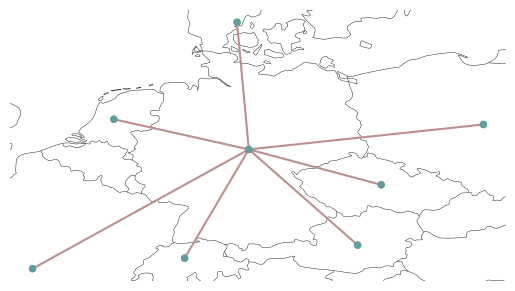

In [104]:
network_0.plot()

In [16]:
network_0.optimize(solver_name="gurobi")

Index(['DNK_load', 'NLD_load', 'POL_load', 'FRA_load', 'AUT_load', 'CHE_load',
       'CZE_load'],
      dtype='object', name='Load')
Index(['DEU_elec', 'elec_store', 'DNK_elec', 'DNK_elec_store', 'NLD_elec',
       'NLD_elec_store', 'POL_elec', 'POL_elec_store', 'FRA_elec',
       'FRA_elec_store', 'AUT_elec', 'AUT_elec_store', 'CHE_elec',
       'CHE_elec_store', 'CZE_elec', 'CZE_elec_store'],
      dtype='object', name='Bus')
Index(['DEU-DNK', 'DEU-NLD', 'DEU-POL', 'DEU-FRA', 'DEU-AUT', 'DEU-CHE',
       'DEU-CZE'],
      dtype='object', name='Line')
Index(['Battery Storage Store', 'DNK Battery Storage Store',
       'NLD Battery Storage Store', 'POL Battery Storage Store',
       'FRA Battery Storage Store', 'AUT Battery Storage Store',
       'CHE Battery Storage Store', 'CZE Battery Storage Store'],
      dtype='object', name='Store')
Index(['grid to battergy storage', 'battery storage to grid',
       'DNK grid to battergy storage', 'DNK battery storage to grid',
       'NLD gri

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2625590


INFO:gurobipy:Set parameter LicenseID to value 2625590


...

Solved in 55943 iterations and 41.24 seconds (56.46 work units)


INFO:gurobipy:Solved in 55943 iterations and 41.24 seconds (56.46 work units)


Optimal objective  1.336964523e+11


INFO:gurobipy:Optimal objective  1.336964523e+11
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 595733 primals, 1261499 duals
Objective: 1.34e+11
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

### Scenario 2: 10GW transfer capacity

In [ ]:
network_10 = base.build_network(solve=False)
country = "DEU"

network_10.add("GlobalConstraint", "CO2Limit",
        carrier_attribute="co2_emissions",
        sense="<=",
        constant=co2_allowance_2040)

# add battery germany
#Create a new bus
network_10.add("Bus",
          "elec_store",
          carrier = "battery storage",
          y = coordinates[country][0],
          x = coordinates[country][1],
          overwrite=True)

#Connect the store to the bus
network_10.add("Store",
          "Battery Storage Store",
          bus = "elec_store",
          e_nom_extendable = True,
          e_cyclic = True,
          capital_cost = costs.at["battery storage", "capital_cost"],
          overwrite=True)

network_10.add("Link",
          "grid to battergy storage",
          bus0 = f"{country}_elec",
          bus1 = "elec_store",
          p_nom_extendable = True,
          efficiency = costs.at["battery inverter", "efficiency"],
          capital_cost = costs.at["battery inverter", "efficiency"],
          overwrite=True)

network_10.add("Link",
          "battery storage to grid",
          bus0 = "elec_store",
          bus1 = f"{country}_elec",
          p_nom_extendable = True,
          efficiency = costs.at["battery inverter", "efficiency"],
          capital_cost = costs.at["battery inverter", "efficiency"],
          overwrite=True
          )

for country in countries[1:]:
    # add demand 
    network_10.add("Bus",
                f"{country}_elec",
                y = coordinates[country][0],
                x = coordinates[country][1],
                carrier="AC")
    network_10.add("Load", 
                f"{country}_load",
                bus=f"{country}_elec",
                p_set=df_elec[country].values,
                carrier = "AC")
    
    # add storage
    network_10.add("Bus",
          f"{country}_elec_store",
          carrier = "battery storage",
          y = coordinates[country][0],
          x = coordinates[country][1],
          overwrite=True)
    network_10.add("Store",
          f"{country} Battery Storage Store",
          bus = f"{country}_elec_store",
          e_nom_extendable = True,
          e_cyclic = True,
          capital_cost = costs.at["battery storage", "capital_cost"],
          overwrite=True)

    network_10.add("Link",
            f"{country} grid to battergy storage",
            bus0 = f"{country}_elec",
            bus1 = f"{country}_elec_store",
            p_nom_extendable = True,
            efficiency = costs.at["battery inverter", "efficiency"],
            capital_cost = costs.at["battery inverter", "efficiency"],
            overwrite=True)

    network_10.add("Link",
            f"{country} battery storage to grid",
            bus0 = f"{country}_elec_store",
            bus1 = f"{country}_elec",
            p_nom_extendable = True,
            efficiency = costs.at["battery inverter", "efficiency"],
            capital_cost = costs.at["battery inverter", "efficiency"],
            overwrite=True
            )
    # add generators
    network_10.add(
        "Generator",
        f"{country}_OCGT",
        bus=f"{country}_elec",
        carrier="OCGT",
        capital_cost=costs.at["OCGT", "capital_cost"],
        marginal_cost=costs.at["OCGT", "marginal_cost"],
        efficiency=costs.at["OCGT", "efficiency"],
        p_nom_extendable=True,
    )   
    CF_wind = df_onshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network_10.snapshots]]
    network_10.add("Generator",
        f"{country}_onwind",
        bus=f"{country}_elec",
        carrier="onwind",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu=CF_wind.values,
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )
    CF_solar = df_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network_10.snapshots]]
    network_10.add("Generator",
        f"{country}_solar",
        bus=f"{country}_elec",
        carrier="solar",
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        p_max_pu=CF_solar.values,
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )
    network_10.add(
        "Line",
        f"DEU-{country}",
        bus0="DEU_elec",
        bus1=f"{country}_elec",
        s_nom_extendable=False, 
        s_nom = 10000,
        x = 1,
        r = 1,
        capital_cost = costs.at["HVAC overhead", "capital_cost"] * line_length[country],
    )

network_10

/Users/jonaswiendl/Documents/46770_IEG/46770_IEG/base.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["Inflow [MW]"] = df_daily["Inflow [GWh]"] * 1000 / 24  # MW average per hour


Unnamed PyPSA Network
---------------------
Components:
 - Bus: 16
 - Carrier: 10
 - Generator: 29
 - GlobalConstraint: 1
 - Line: 7
 - Link: 16
 - Load: 8
 - Store: 8
Snapshots: 8760

In [18]:
network_10.optimize(solver_name="gurobi")

Index(['DNK_load', 'NLD_load', 'POL_load', 'FRA_load', 'AUT_load', 'CHE_load',
       'CZE_load'],
      dtype='object', name='Load')
Index(['DEU_elec', 'elec_store', 'DNK_elec', 'DNK_elec_store', 'NLD_elec',
       'NLD_elec_store', 'POL_elec', 'POL_elec_store', 'FRA_elec',
       'FRA_elec_store', 'AUT_elec', 'AUT_elec_store', 'CHE_elec',
       'CHE_elec_store', 'CZE_elec', 'CZE_elec_store'],
      dtype='object', name='Bus')
Index(['DEU-DNK', 'DEU-NLD', 'DEU-POL', 'DEU-FRA', 'DEU-AUT', 'DEU-CHE',
       'DEU-CZE'],
      dtype='object', name='Line')
Index(['Battery Storage Store', 'DNK Battery Storage Store',
       'NLD Battery Storage Store', 'POL Battery Storage Store',
       'FRA Battery Storage Store', 'AUT Battery Storage Store',
       'CHE Battery Storage Store', 'CZE Battery Storage Store'],
      dtype='object', name='Store')
Index(['grid to battergy storage', 'battery storage to grid',
       'DNK grid to battergy storage', 'DNK battery storage to grid',
       'NLD gri

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2625590


INFO:gurobipy:Set parameter LicenseID to value 2625590


...

Solved in 121951 iterations and 94.04 seconds (117.01 work units)


INFO:gurobipy:Solved in 121951 iterations and 94.04 seconds (117.01 work units)


Optimal objective  1.123262956e+11


INFO:gurobipy:Optimal objective  1.123262956e+11
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 595733 primals, 1261499 duals
Objective: 1.12e+11
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

### Scenario 3: unlimited capacity, endogenously optimised

In [ ]:
network_unlimited = base.build_network(solve=False)
country = "DEU"

network_unlimited.add("GlobalConstraint", "CO2Limit",
        carrier_attribute="co2_emissions",
        sense="<=",
        constant=co2_allowance_2040)

# add battery germany
#Create a new bus
network_unlimited.add("Bus",
          "elec_store",
          carrier = "battery storage",
          y = coordinates[country][0],
          x = coordinates[country][1],
          overwrite=True)

#Connect the store to the bus
network_unlimited.add("Store",
          "Battery Storage Store",
          bus = "elec_store",
          e_nom_extendable = True,
          e_cyclic = True,
          capital_cost = costs.at["battery storage", "capital_cost"],
          overwrite=True)

network_unlimited.add("Link",
          "grid to battergy storage",
          bus0 = f"{country}_elec",
          bus1 = "elec_store",
          p_nom_extendable = True,
          efficiency = costs.at["battery inverter", "efficiency"],
          capital_cost = costs.at["battery inverter", "efficiency"],
          overwrite=True)

network_unlimited.add("Link",
          "battery storage to grid",
          bus0 = "elec_store",
          bus1 = f"{country}_elec",
          p_nom_extendable = True,
          efficiency = costs.at["battery inverter", "efficiency"],
          capital_cost = costs.at["battery inverter", "efficiency"],
          overwrite=True
          )

for country in countries[1:]:
    # add demand 
    network_unlimited.add("Bus",
                f"{country}_elec",
                y = coordinates[country][0],
                x = coordinates[country][1],
                carrier="AC")
    network_unlimited.add("Load", 
                f"{country}_load",
                bus=f"{country}_elec",
                p_set=df_elec[country].values,
                carrier = "AC")
    
    # add storage
    network_unlimited.add("Bus",
          f"{country}_elec_store",
          carrier = "battery storage",
          y = coordinates[country][0],
          x = coordinates[country][1],
          overwrite=True)
    network_unlimited.add("Store",
          f"{country} Battery Storage Store",
          bus = f"{country}_elec_store",
          e_nom_extendable = True,
          e_cyclic = True,
          capital_cost = costs.at["battery storage", "capital_cost"],
          overwrite=True)

    network_unlimited.add("Link",
            f"{country} grid to battergy storage",
            bus0 = f"{country}_elec",
            bus1 = f"{country}_elec_store",
            p_nom_extendable = True,
            efficiency = costs.at["battery inverter", "efficiency"],
            capital_cost = costs.at["battery inverter", "efficiency"],
            overwrite=True)

    network_unlimited.add("Link",
            f"{country} battery storage to grid",
            bus0 = f"{country}_elec_store",
            bus1 = f"{country}_elec",
            p_nom_extendable = True,
            efficiency = costs.at["battery inverter", "efficiency"],
            capital_cost = costs.at["battery inverter", "efficiency"],
            overwrite=True
            )
    # add generators
    network_unlimited.add(
        "Generator",
        f"{country}_OCGT",
        bus=f"{country}_elec",
        carrier="OCGT",
        capital_cost=costs.at["OCGT", "capital_cost"],
        marginal_cost=costs.at["OCGT", "marginal_cost"],
        efficiency=costs.at["OCGT", "efficiency"],
        p_nom_extendable=True,
    )   
    CF_wind = df_onshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network_unlimited.snapshots]]
    network_unlimited.add("Generator",
        f"{country}_onwind",
        bus=f"{country}_elec",
        carrier="onwind",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu=CF_wind.values,
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )
    CF_solar = df_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network_unlimited.snapshots]]
    network_unlimited.add("Generator",
        f"{country}_solar",
        bus=f"{country}_elec",
        carrier="solar",
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        p_max_pu=CF_solar.values,
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )
    network_unlimited.add(
        "Line",
        f"DEU-{country}",
        bus0="DEU_elec",
        bus1=f"{country}_elec",
        s_nom_extendable=True, 
        s_nom = 0,
        x = 1,
        r = 1,
        capital_cost = costs.at["HVAC overhead", "capital_cost"] * line_length[country],
    )

network_unlimited

/Users/jonaswiendl/Documents/46770_IEG/46770_IEG/base.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["Inflow [MW]"] = df_daily["Inflow [GWh]"] * 1000 / 24  # MW average per hour


Unnamed PyPSA Network
---------------------
Components:
 - Bus: 16
 - Carrier: 10
 - Generator: 29
 - GlobalConstraint: 1
 - Line: 7
 - Link: 16
 - Load: 8
 - Store: 8
Snapshots: 8760

In [20]:
network_unlimited.optimize(solver_name="gurobi")

Index(['DNK_load', 'NLD_load', 'POL_load', 'FRA_load', 'AUT_load', 'CHE_load',
       'CZE_load'],
      dtype='object', name='Load')
Index(['DEU_elec', 'elec_store', 'DNK_elec', 'DNK_elec_store', 'NLD_elec',
       'NLD_elec_store', 'POL_elec', 'POL_elec_store', 'FRA_elec',
       'FRA_elec_store', 'AUT_elec', 'AUT_elec_store', 'CHE_elec',
       'CHE_elec_store', 'CZE_elec', 'CZE_elec_store'],
      dtype='object', name='Bus')
Index(['DEU-DNK', 'DEU-NLD', 'DEU-POL', 'DEU-FRA', 'DEU-AUT', 'DEU-CHE',
       'DEU-CZE'],
      dtype='object', name='Line')
Index(['Battery Storage Store', 'DNK Battery Storage Store',
       'NLD Battery Storage Store', 'POL Battery Storage Store',
       'FRA Battery Storage Store', 'AUT Battery Storage Store',
       'CHE Battery Storage Store', 'CZE Battery Storage Store'],
      dtype='object', name='Store')
Index(['grid to battergy storage', 'battery storage to grid',
       'DNK grid to battergy storage', 'DNK battery storage to grid',
       'NLD gri

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2625590


INFO:gurobipy:Set parameter LicenseID to value 2625590


...

Solved in 156909 iterations and 68.97 seconds (81.35 work units)


INFO:gurobipy:Solved in 156909 iterations and 68.97 seconds (81.35 work units)


Optimal objective  1.040190360e+11


INFO:gurobipy:Optimal objective  1.040190360e+11
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 595740 primals, 1261506 duals
Objective: 1.04e+11
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-ext-s-lower, Line-ext-s-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

### Analysis

In [87]:
def get_line_energy(network):
    power_flow = network.lines_t.p0  # MW per time step
    timestep_in_hours = (network.snapshots[1] - network.snapshots[0]).total_seconds() / 3600
    energy_flow = (power_flow * timestep_in_hours).sum(axis=0)  # MWh
    return energy_flow

# Calculate energy flows
energy_flow_0 = get_line_energy(network_0)
energy_flow_10 = get_line_energy(network_10)
energy_flow_uncapped = get_line_energy(network_unlimited)


# Create a single DataFrame
energy_flows = pd.DataFrame({
    "0 GW": energy_flow_0,
    "10 GW": energy_flow_10,
    "Uncapped": energy_flow_uncapped
})

# Optional: reset index if you want line names as a column
energy_flows = energy_flows.reset_index().rename(columns={"index": "Line"})

energy_flows


,Line,0 GW,10 GW,Uncapped
0,DEU-DNK,0.0,-4.177779e+07,-1.903082e+08
1,DEU-NLD,0.0,-8.263678e+06,1.040587e+08
2,DEU-POL,0.0,9.619044e+06,1.752347e+07
3,DEU-FRA,0.0,-9.707703e+06,-1.096487e+08
4,DEU-AUT,0.0,-2.679256e+06,-1.999222e+08
5,DEU-CHE,0.0,-3.431157e+07,2.950154e+07
6,DEU-CZE,0.0,2.037549e+07,5.061069e+07


In [ ]:
def calculate_renewable_share(network):
    df = network.generators_t.p.sum().div(1e6).to_frame()
    df.reset_index(inplace=True)
    ocgt_share=df[df["Generator"].str.contains("OCGT")][0].sum()
    renewables=(df[0].sum()-ocgt_share)/df[0].sum()
    return renewables

def calculate_congestion_rent(network, countries):
    # Congestion rent
    rent_list = []
    for country in countries[1:]:
        rent = ((network.buses_t.marginal_price["DEU_elec"] - network.buses_t.marginal_price[f"{country}_elec"]) * network.lines_t.p0[f"DEU-{country}"]).sum()
        rent_list.append(rent)

    return abs(sum(rent_list))

def extract_kpis(network, scenario_name):
    # 1. Total System Cost (Objective function value)
    total_system_cost = network.objective / 1e9  # [billion €]
    
    # 2. Net Import/Export for Germany
    net_import = network.lines_t.p0[network.lines_t.p0 < 0].sum().sum()/(1e6)
    net_export = network.lines_t.p0[network.lines_t.p0 > 0].sum().sum()/(1e6)
    net_import_export = network.lines_t.p0.sum().sum()/(1e6)

    # 3. System Share of Renewables
    renewable_share = calculate_renewable_share(network)

    # 4. Transmission Investment Costs
    line_costs = (network.lines.s_nom_opt * network.lines.capital_cost).sum()/1e6  # line capacity * €/MW

    # 5. Total Congestion Costs
    congestion_costs = calculate_congestion_rent(network, countries)/1e6

    return {
        "Scenario": scenario_name,
        "Total System Cost (billion €)": total_system_cost,
        "Net Import (GWh)": net_import,
        "Net Export (GWh)": net_export,
        "Net Flow Germany (GWh)": net_import_export,
        "Renewable Share (%)": renewable_share * 100,
        "Transmission Investment Costs (Mio €)": line_costs,
        "Congestion Rent (Mio €)": congestion_costs
    }

# First, find the timestep
timestep_in_hours = (network_0.snapshots[1] - network_0.snapshots[0]).total_seconds() / 3600

# Collect data
kpi_0 = extract_kpis(network_0, "0 GW")
kpi_10 = extract_kpis(network_10, "10 GW")
kpi_unlimited = extract_kpis(network_unlimited, "Unlimited")

# Create DataFrame
kpi_table = pd.DataFrame([kpi_0, kpi_10, kpi_unlimited])
kpi_table.round(2)


,Scenario,Total System Cost (billion €),Net Import (GWh),Net Export (GWh),Net Flow Germany (GWh),Renewable Share (%),Transmission Investment Costs (Mio €),Congestion Rent (Mio €)
0,0 GW,133.70,0.00,0.00,0.00,87.77,0.00,0.00
1,10 GW,112.33,-244.75,178.00,-66.75,84.96,273.05,5902.84
2,Unlimited,104.02,-620.62,322.44,-298.18,85.21,1038.87,1038.87


In [103]:
round(network_unlimited.lines.s_nom_opt.to_frame().T/1e3).round(0)

Line,DEU-DNK,DEU-NLD,DEU-POL,DEU-FRA,DEU-AUT,DEU-CHE,DEU-CZE
s_nom_opt,77.0,17.0,26.0,52.0,70.0,8.0,10.0


In [106]:
network_10.lines_t.p0[network_10.lines_t.p0 > 0].sum().to_frame()

,0
Line,
DEU-DNK,9.605559e+06
DEU-NLD,2.382536e+07
DEU-POL,3.587292e+07
DEU-FRA,3.293703e+07
DEU-AUT,2.518223e+07
DEU-CHE,1.681532e+07
DEU-CZE,3.376280e+07


In [ ]:
df = network_10.lines_t.p0[network_10.lines_t.p0 > 0].sum()

# Sum only positive values per column
positive_sums = df[df > 0].sum()

# Sum only negative values per column
negative_sums = df[df < 0].sum()

# Display
print("Sum of positive values:")
print(positive_sums)

print("\nSum of negative values:")
print(negative_sums)

print("\nOverall:")
print(network_10.lines_t.p0.sum().sum())


Sum of positive values:
Line
DEU-DNK    9.605559e+06
DEU-NLD    2.382536e+07
DEU-POL    3.587292e+07
DEU-FRA    3.293703e+07
DEU-AUT    2.518223e+07
DEU-CHE    1.681532e+07
DEU-CZE    3.376280e+07
dtype: float64

Sum of negative values:
Line
DEU-DNK   -5.138335e+07
DEU-NLD   -3.208904e+07
DEU-POL   -2.625388e+07
DEU-FRA   -4.264473e+07
DEU-AUT   -2.786149e+07
DEU-CHE   -5.112690e+07
DEU-CZE   -1.338731e+07
dtype: float64

Overall:
Line
DEU-DNK   -4.177779e+07
DEU-NLD   -8.263678e+06
DEU-POL    9.619044e+06
DEU-FRA   -9.707703e+06
DEU-AUT   -2.679256e+06
DEU-CHE   -3.431157e+07
DEU-CZE    2.037549e+07
dtype: float64
